# Diabetes Prediction (Numerical Data)
### Gaussian Naive Bayes
**Goal:** Predict whether a patient has **diabetes (1)** or **not (0)** based on diagnostic measurements.

---
## Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Load the Dataset

In [2]:

df = pd.read_csv('diabetes.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Explore the Dataset

In [3]:

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class distribution (0 = No Diabetes, 1 = Diabetes):
Outcome
0    500
1    268
Name: count, dtype: int64


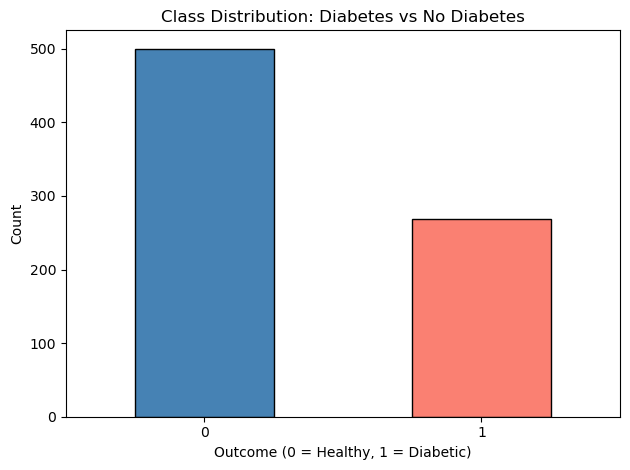

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Class distribution
print("\nClass distribution (0 = No Diabetes, 1 = Diabetes):")
print(df['Outcome'].value_counts())

# Visualize class balance
df['Outcome'].value_counts().plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black'
)
plt.title('Class Distribution: Diabetes vs No Diabetes')
plt.xlabel('Outcome (0 = Healthy, 1 = Diabetic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Data Preprocessing
> Some columns use **0** as a placeholder for missing data (e.g., Glucose cannot be 0 biologically). We replace those zeros with the column mean.

In [6]:
# These columns cannot realistically be zero — treat 0 as missing
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_not_valid:
    # Count zeros before replacement
    zeros = (df[col] == 0).sum()
    # Replace 0 with NaN, then fill NaN with column mean
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].mean())
    print(f"  {col:18s} → replaced {zeros} zeros with mean = {df[col].mean():.2f}")

print("\nPreprocessing done. Remaining nulls:", df.isnull().sum().sum())

#We use this technique(mean imputation) To fill in missing/invalid values without deleting rows

  Glucose            → replaced 5 zeros with mean = 121.69
  BloodPressure      → replaced 35 zeros with mean = 72.41
  SkinThickness      → replaced 227 zeros with mean = 29.15
  Insulin            → replaced 374 zeros with mean = 155.55
  BMI                → replaced 11 zeros with mean = 32.46

Preprocessing done. Remaining nulls: 0


In [7]:
# Separate features (X) and target variable (y)
X = df.drop('Outcome', axis=1)   # all columns except the label
y = df['Outcome']                # target: 0 or 1

print("Features shape :", X.shape)
print("Target  shape  :", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape : (768, 8)
Target  shape  : (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


---
## Train / Test Split

In [8]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 614
Testing  samples : 154


---
## Train the Gaussian Naive Bayes Model
> **Gaussian NB** is used for continuous/numerical features. It assumes each feature follows a normal (Gaussian) distribution.

In [10]:
# Create and train the Gaussian Naive Bayes model

gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


---
## Predictions

In [12]:
# Predict class labels on the test set
y_pred = gnb.predict(X_test)

# Predict class probabilities 
y_proba = gnb.predict_proba(X_test)



---
## Model Evaluation (Metrics)

In [14]:

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print("=====================================")
print("   Gaussian Naive Bayes — Results    ")
print("=====================================")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)']))

   Gaussian Naive Bayes — Results    
  Accuracy  : 0.6948
  Precision : 0.5574
  Recall    : 0.6296
  F1-Score  : 0.5913

Classification Report:
                 precision    recall  f1-score   support

No Diabetes (0)       0.78      0.73      0.76       100
   Diabetes (1)       0.56      0.63      0.59        54

       accuracy                           0.69       154
      macro avg       0.67      0.68      0.67       154
   weighted avg       0.71      0.69      0.70       154



---
## Confusion Matrix (Visualized)

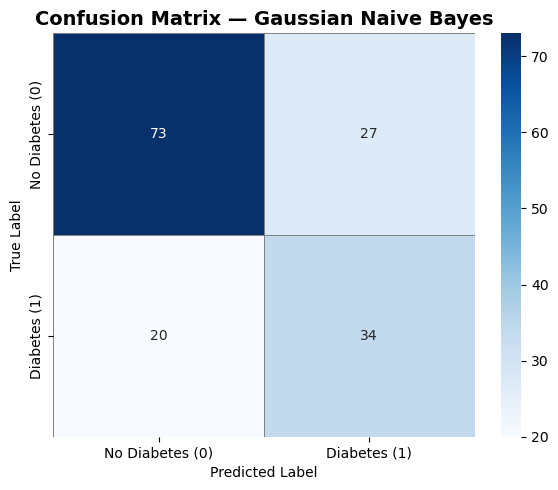

True Negatives  (TN): 73  → Correctly predicted No Diabetes
False Positives (FP): 27  → Incorrectly predicted Diabetes
False Negatives (FN): 20  → Missed actual Diabetes cases
True Positives  (TP): 34  → Correctly predicted Diabetes


In [15]:

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
    yticklabels=['No Diabetes (0)', 'Diabetes (1)'],
    linewidths=0.5, linecolor='gray'
)
plt.title('Confusion Matrix — Gaussian Naive Bayes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  → Correctly predicted No Diabetes")
print(f"False Positives (FP): {fp}  → Incorrectly predicted Diabetes")
print(f"False Negatives (FN): {fn}  → Missed actual Diabetes cases")
print(f"True Positives  (TP): {tp}  → Correctly predicted Diabetes")

---
## Metrics Bar Chart

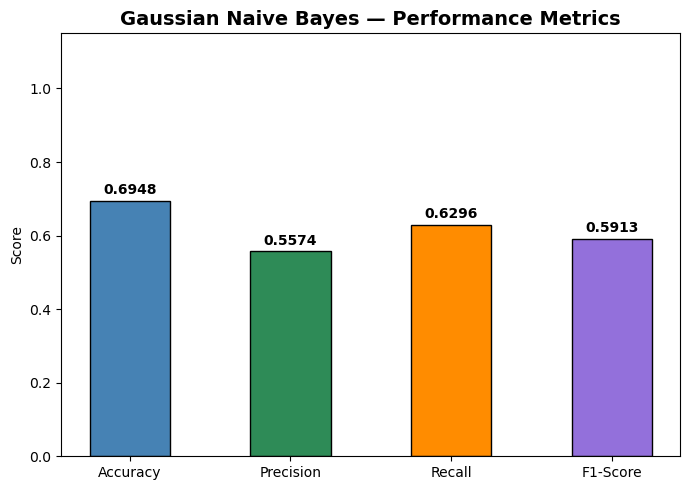

In [16]:
# Visualize all metrics in a bar chart for a quick summary
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [accuracy, precision, recall, f1]

colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}', ha='center', va='bottom', fontweight='bold'
    )

plt.title('Gaussian Naive Bayes — Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()